# Processing ERRORR Files with Andalus

This notebook demonstrates how to create an `andalus.Covariance` object from ERRORR output files and prepare the data for database storage.

### Background
We use the `sandy` library to parse ERRORR files and combine covariance matrices. Currently, `andalus` supports reading covariance information from the following sections:

* **File 31 (MF31):** $\bar{\nu}$ (nubar)
* **File 33 (MF33):** Cross sections
* **File 34 (MF34):** Angular distributions
* **File 35 (MF35):** Energy distributions

> **Note on Identifiers:** Since MT numbers in MF34 and MF35 may overlap with those in MF33, we ensure uniqueness in MF34/35 by defining the identifier as:  
> `Identifier = (MF * 1000) + MT`

### 1. Setup and Imports
We import `andalus` to handle the covariance objects. Internally, `andalus` leverages `sandy` to parse the raw text into structured `pandas` DataFrames.

In [126]:
import matplotlib.pyplot as plt

import andalus

### 2. Reading ERRORR Output
Raw ERRORR files use a specific nuclear data format that is difficult to parse manually. Below is a snippet of the raw input data:

In [37]:
!head -10 "../data/u235.errorr31"

                                                                     1 0  0    0
 9.223500+4 2.330248+2          6          0        -11          09228 1451    1
 0.000000+0 0.000000+0         33          0         34          09228 1451    2
 1.000000-5 1.000000-1 5.400000-1 4.000000+0 8.315290+0 1.370960+19228 1451    3
 2.260330+1 4.016900+1 6.790400+1 9.166090+1 1.486250+2 3.043250+29228 1451    4
 4.539990+2 7.485180+2 1.234100+3 2.034680+3 3.354630+3 5.530840+39228 1451    5
 9.118820+3 1.503440+4 2.478750+4 4.086770+4 6.737950+4 1.110900+59228 1451    6
 1.831560+5 3.019740+5 4.978710+5 8.208500+5 1.353350+6 2.231300+69228 1451    7
 3.678790+6 6.065310+6 1.000000+7 1.964030+7                      9228 1451    8
                                                                  9228 1  099999


The `Covariance.from_errorr` method simplifies this process. You provide a dictionary mapping the error types (keys) to their file paths, specify the **ZAI** (isotope identifier), and optionally provide a list of **MT** numbers to extract.

In [133]:
files = {
    "errorr33": "../data/u235.errorr33",
    "errorr31": "../data/u235.errorr31",
    "errorr34": "../data/u235.errorr34",
    "errorr35": "../data/u235.errorr35",
}

cov = andalus.Covariance.from_errorr(files, zai=922350, mts=[1, 2, 4, 18, 102, 456, 34251, 35018])

### 3. Exploring the Covariance Object
The resulting object inherits from `pandas.DataFrame`, meaning you can use standard data manipulation tools. However, it also contains nuclear-specific metadata like `zai`, `nuclide`, and optional physics parameters like `temperature` or `tolerance`.

In [134]:
print(f"ZAI: {cov.zai}")
print(f"Nuclide: {cov.nuclide}")
?cov

ZAI: 922350
Nuclide: U235


Type:        Covariance
String form:
MT                                  1                                          \
           E_min_eV         <...> 1.00000e+07  3.95538e-03
           1.00000e+07 1.96403e+07  1.96065e-02
           
           [264 rows x 264 columns]
Length:      264
File:        c:\users\dhouben\documents\andalus\src\andalus\covariance.py
Docstring:  
Subclass of pd.DataFrame for handling individual nuclide covariance data.

Attributes
----------
zai : int
    Nuclide identifier (ZAI).
temperature : float, optional
    Temperature at which the covariance was generated.
err : float, optional
    Associated error or tolerance.

### 4. Correlation Matrix Visualization
We can easily derive a correlation matrix from our covariance data and visualize it using a heat map.

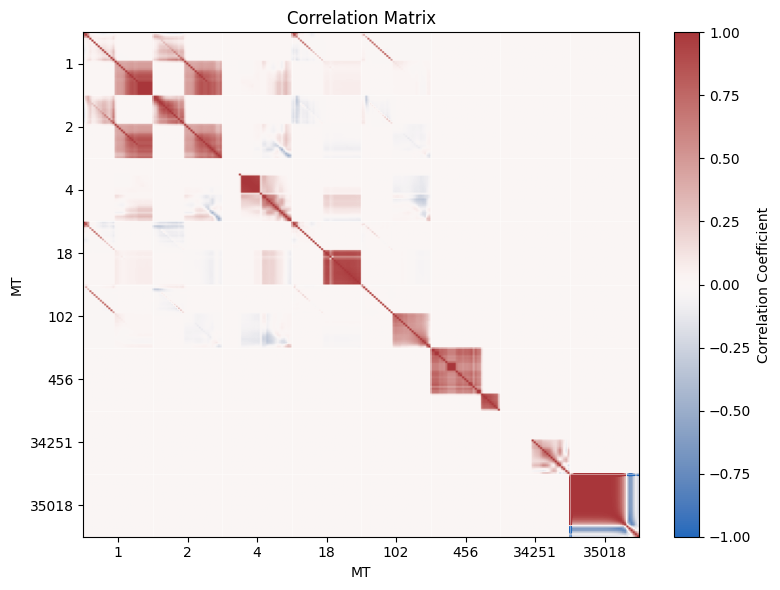

In [135]:
corr = cov.correlation()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="vlag", aspect="auto")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation Coefficient")

ax.set_title("Correlation Matrix")
ax.set_xlabel("Index")
ax.set_ylabel("Index")

lvl0 = corr.index.get_level_values(0)

# find contiguous MT blocks
blocks = []
start = 0
for i in range(1, len(lvl0)):
    if lvl0[i] != lvl0[i - 1]:
        blocks.append((lvl0[i - 1], start, i - 1))
        start = i
blocks.append((lvl0[-1], start, len(lvl0) - 1))

# tick at block centers
tick_pos = [(s + e) / 2 for _, s, e in blocks]
tick_labels = [str(mt) for mt, _, _ in blocks]

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_labels)

# optional separators between MT blocks
for _, _, e in blocks[:-1]:
    ax.axvline(e + 0.5, color="white", lw=0.5, alpha=0.6)
    ax.axhline(e + 0.5, color="white", lw=0.5, alpha=0.6)

ax.set_xlabel("MT")
ax.set_ylabel("MT")

plt.tight_layout()

### 5. Exporting Data
Once the data is processed, it can be exported to a format optimized for use in ANDALUS.

In [53]:
cov.to_hdf5("u235_cov.h5")

And it can then be easily read.

In [66]:
andalus.Covariance.from_hdf5("u235_cov.h5", zai=922350)

MT                                  456                                        \
E_min                         1.00000e-05 1.00000e-01 5.40000e-01 4.00000e+00   
E_max                         1.00000e-01 5.40000e-01 4.00000e+00 8.31529e+00   
MT    E_min       E_max                                                         
456   1.00000e-05 1.00000e-01 2.05760e-05 2.05760e-05 1.79154e-05 1.76400e-05   
      1.00000e-01 5.40000e-01 2.05760e-05 2.05760e-05 1.79154e-05 1.76400e-05   
      5.40000e-01 4.00000e+00 1.79154e-05 1.79154e-05 2.00769e-05 2.03007e-05   
      4.00000e+00 8.31529e+00 1.76400e-05 1.76400e-05 2.03007e-05 2.05760e-05   
      8.31529e+00 1.37096e+01 1.76400e-05 1.76400e-05 1.84709e-05 1.85570e-05   
...                                   ...         ...         ...         ...   
35018 1.35335e+06 2.23130e+06 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      2.23130e+06 3.67879e+06 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      3.67879e+06 6.06531e+06 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      6.06531e+06 1.00000e+07 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      1.00000e+07 1.96403e+07 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   

MT                                                                             \
E_min                         8.31529e+00 1.37096e+01 2.26033e+01 4.01690e+01   
E_max                         1.37096e+01 2.26033e+01 4.01690e+01 6.79040e+01   
MT    E_min       E_max                                                         
456   1.00000e-05 1.00000e-01 1.76400e-05 1.76400e-05 1.76400e-05 1.76400e-05   
      1.00000e-01 5.40000e-01 1.76400e-05 1.76400e-05 1.76400e-05 1.76400e-05   
      5.40000e-01 4.00000e+00 1.84709e-05 1.76400e-05 1.76400e-05 1.76400e-05   
      4.00000e+00 8.31529e+00 1.85570e-05 1.76400e-05 1.76400e-05 1.76400e-05   
      8.31529e+00 1.37096e+01 2.71709e-05 1.95905e-05 1.76400e-05 1.76400e-05   
...                                   ...         ...         ...         ...   
35018 1.35335e+06 2.23130e+06 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      2.23130e+06 3.67879e+06 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      3.67879e+06 6.06531e+06 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      6.06531e+06 1.00000e+07 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   
      1.00000e+07 1.96403e+07 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00   

MT                                                     ...        35018  \
E_min                         6.79040e+01 9.16609e+01  ...  1.11090e+05   
E_max                         9.16609e+01 1.48625e+02  ...  1.83156e+05   
MT    E_min       E_max                                ...                
456   1.00000e-05 1.00000e-01 1.76400e-05 1.76400e-05  ...  0.00000e+00   
      1.00000e-01 5.40000e-01 1.76400e-05 1.76400e-05  ...  0.00000e+00   
      5.40000e-01 4.00000e+00 1.76400e-05 1.76400e-05  ...  0.00000e+00   
      4.00000e+00 8.31529e+00 1.76400e-05 1.76400e-05  ...  0.00000e+00   
      8.31529e+00 1.37096e+01 1.76400e-05 1.76400e-05  ...  0.00000e+00   
...                                   ...         ...  ...          ...   
35018 1.35335e+06 2.23130e+06 0.00000e+00 0.00000e+00  ... -8.24541e-04   
      2.23130e+06 3.67879e+06 0.00000e+00 0.00000e+00  ... -7.69174e-04   
      3.67879e+06 6.06531e+06 0.00000e+00 0.00000e+00  ... -6.33792e-04   
      6.06531e+06 1.00000e+07 0.00000e+00 0.00000e+00  ... -5.45683e-04   
      1.00000e+07 1.96403e+07 0.00000e+00 0.00000e+00  ... -1.32210e-03   

MT                                                                    \
E_min                          1.83156e+05  3.01974e+05  4.97871e+05   
E_max                          3.01974e+05  4.97871e+05  8.20850e+05   
MT    E_min       E_max                                                
456   1.00000e-05 1.00000e-01  0.00000e+00  0.00000e+00  0.00000e+00   
      1.00000e-01 5.40000e-01  0.00000e+00  0.00000e+00  0.00000e+00   
      5.40